In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 3.221199999999255 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.5.20                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.17                          pyhcf101f3_0                  conda-forge                   
+ joblib                     

In [4]:
df1 = pd.read_csv("mental_health_and_technology_usage_2024.csv")
df2 = pd.read_csv("social_media_sleep_stress_productivity_11000.csv")

In [5]:
#view first five rows of file one
df1.head()

,User_ID,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Mental_Health_Status,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage
0,USER-00001,23,Female,6.57,6.00,0.68,12.36,Good,Low,8.01,6.71,No,Negative,Yes
1,USER-00002,21,Male,3.01,2.57,3.74,7.61,Poor,High,7.28,5.88,Yes,Positive,No
2,USER-00003,51,Male,3.04,6.14,1.26,3.16,Fair,High,8.04,9.81,No,Negative,No
3,USER-00004,25,Female,3.84,4.48,2.59,13.08,Excellent,Medium,5.62,5.28,Yes,Negative,Yes
4,USER-00005,53,Male,1.20,0.56,0.29,12.63,Good,Low,5.55,4.00,No,Positive,Yes


In [6]:
df1.shape

(10000, 14)

In [8]:
#Are there missing values in the data set? (Count missing values)
df1.isna().sum()

User_ID                     0
Age                         0
Gender                      0
Technology_Usage_Hours      0
Social_Media_Usage_Hours    0
Gaming_Hours                0
Screen_Time_Hours           0
Mental_Health_Status        0
Stress_Level                0
Sleep_Hours                 0
Physical_Activity_Hours     0
Support_Systems_Access      0
Work_Environment_Impact     0
Online_Support_Usage        0
dtype: int64

In [9]:
#view first five rows of file two
df2.head()

,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score,stress_level,platform
0,1,44,2.39,1.93,8.46,61,3.73,33.86,Low,YouTube
1,2,30,7.22,5.24,7.34,28,6.80,85.32,Low,YouTube
2,3,23,2.56,4.64,4.69,8,4.47,60.07,High,YouTube
3,4,36,8.75,4.89,5.05,53,9.53,36.46,Medium,LinkedIn
4,5,34,10.96,2.77,7.12,83,7.01,32.93,Medium,Instagram


In [10]:
df2.shape

(11000, 10)

In [11]:
#Are there missing values in the data set? Count missing values
df2.isna().sum()

user_id                    0
age                        0
daily_screen_time_hours    0
social_media_hours         0
sleep_hours                0
exercise_minutes           0
study_work_hours           0
productivity_score         0
stress_level               0
platform                   0
dtype: int64

In [12]:
#combine the two data sets
combined = pd.concat([df1, df2], ignore_index=True, sort=False)

In [13]:
#show first five rows of new combined data set
combined.head()

,User_ID,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Mental_Health_Status,Stress_Level,Sleep_Hours,...,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score,stress_level,platform
0,USER-00001,23.0,Female,6.57,6.00,0.68,12.36,Good,Low,8.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USER-00002,21.0,Male,3.01,2.57,3.74,7.61,Poor,High,7.28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USER-00003,51.0,Male,3.04,6.14,1.26,3.16,Fair,High,8.04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USER-00004,25.0,Female,3.84,4.48,2.59,13.08,Excellent,Medium,5.62,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USER-00005,53.0,Male,1.20,0.56,0.29,12.63,Good,Low,5.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
#view the shape of the new combined data set
combined.shape

(21000, 24)

In [15]:
#Show all column names
combined.columns

Index(['User_ID', 'Age', 'Gender', 'Technology_Usage_Hours',
       'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours',
       'Mental_Health_Status', 'Stress_Level', 'Sleep_Hours',
       'Physical_Activity_Hours', 'Support_Systems_Access',
       'Work_Environment_Impact', 'Online_Support_Usage', 'user_id', 'age',
       'daily_screen_time_hours', 'social_media_hours', 'sleep_hours',
       'exercise_minutes', 'study_work_hours', 'productivity_score',
       'stress_level', 'platform'],
      dtype='str')

In [16]:
#rename columns for alignment
df2 = df2.rename(columns={'age': 'Age',
                            'user_id': 'User_ID',
                             'daily_screen_time_hours': 'Screen_Time_Hours',
                             'social_media_hours': 'Social_Media_Usage_Hours',
                             'sleep_hours': 'Sleep_Hours',
                             'exercise_minutes': 'Physical_Activity_Hours',
                             'study_work_hours': 'Study_Work_Hours',
                             'productivity_score': 'Productivity_Score',
                             'stress_level': 'Stress_Level',
                             'platform': 'Platform'})

In [17]:
#combine the two data sets (original file one and renamed file two)
combined = pd.concat([df1, df2], ignore_index=True, sort=False)

In [18]:
#show fist five rows of combine data sets which should now consolidate the columns with the same name (less columns)
combined.head()

,User_ID,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Mental_Health_Status,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage,Study_Work_Hours,Productivity_Score,Platform
0,USER-00001,23,Female,6.57,6.00,0.68,12.36,Good,Low,8.01,6.71,No,Negative,Yes,NaN,NaN,NaN
1,USER-00002,21,Male,3.01,2.57,3.74,7.61,Poor,High,7.28,5.88,Yes,Positive,No,NaN,NaN,NaN
2,USER-00003,51,Male,3.04,6.14,1.26,3.16,Fair,High,8.04,9.81,No,Negative,No,NaN,NaN,NaN
3,USER-00004,25,Female,3.84,4.48,2.59,13.08,Excellent,Medium,5.62,5.28,Yes,Negative,Yes,NaN,NaN,NaN
4,USER-00005,53,Male,1.20,0.56,0.29,12.63,Good,Low,5.55,4.00,No,Positive,Yes,NaN,NaN,NaN


In [19]:
#view the shape of the new combined data set (less columns as now there are seven columns in df2 that are the same as df1)
combined.shape

(21000, 17)

In [20]:
#Are there missing values? Yes (Gender, Technology_Usage_Hours, Gaming_Hours, Mental_Health_Status, Support_Systems_Access, Work_Environment_Impact, Online_Support_Usage, Study_Work_Hours, Productivity_Score, Platform)
combined.isna().sum()

User_ID                         0
Age                             0
Gender                      11000
Technology_Usage_Hours      11000
Social_Media_Usage_Hours        0
Gaming_Hours                11000
Screen_Time_Hours               0
Mental_Health_Status        11000
Stress_Level                    0
Sleep_Hours                     0
Physical_Activity_Hours         0
Support_Systems_Access      11000
Work_Environment_Impact     11000
Online_Support_Usage        11000
Study_Work_Hours            10000
Productivity_Score          10000
Platform                    10000
dtype: int64

In [21]:
#Drop columns with missing values
combined = combined.dropna(axis=1)

In [22]:
#Checking remaining columns and if there are missing values. (NO)
combined.isna().sum()

User_ID                     0
Age                         0
Social_Media_Usage_Hours    0
Screen_Time_Hours           0
Stress_Level                0
Sleep_Hours                 0
Physical_Activity_Hours     0
dtype: int64

In [23]:
#view the shape of the new combined data set 
combined.shape

(21000, 7)

In [24]:
#show overview of all numberical variables
combined.describe()

,Age,Social_Media_Usage_Hours,Screen_Time_Hours,Sleep_Hours,Physical_Activity_Hours
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,36.824714,4.116390,7.232708,6.235440,33.532695
std,12.709313,2.237267,3.685769,1.623875,37.084858
min,16.000000,0.000000,1.000000,3.000000,0.000000
25%,26.000000,2.180000,4.110000,4.880000,4.740000
50%,36.000000,4.110000,7.140000,6.260000,9.580000
75%,46.000000,6.040000,10.210000,7.630000,62.000000
max,65.000000,8.000000,15.000000,9.000000,119.000000


In [25]:
#Age Breakdown
combined['Age'].value_counts()

Age
32    598
41    579
38    578
28    560
43    547
23    545
37    541
44    540
33    538
18    538
34    537
36    537
27    536
21    533
25    531
31    529
40    528
39    528
45    528
29    526
24    523
26    521
30    521
20    517
49    516
48    514
22    510
35    509
46    506
42    501
47    500
19    499
17    328
16    304
62    245
59    235
65    230
50    224
53    218
57    218
52    214
64    208
63    207
56    203
55    198
58    196
54    194
51    191
61    187
60    186
Name: count, dtype: int64

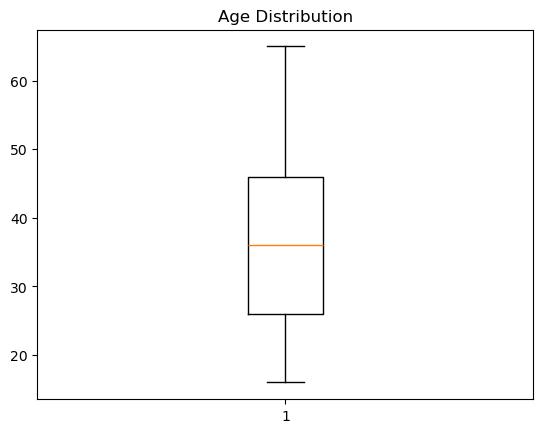

In [27]:
#additional age visualization = particpants concentrated in the 25-48 group
plt.boxplot(combined['Age'])
plt.title('Age Distribution')
plt.show()

In [29]:
#Creating Age Bands
combined["Age_Band"] = pd.cut(
    combined["Age"],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=["Under 18", "18-25", "26-35", "36-45", "46-60", "60+"])

In [30]:
#Stress Level Breakdown
combined['Stress_Level'].value_counts()

Stress_Level
Low       7047
Medium    7019
High      6934
Name: count, dtype: int64

In [32]:
#Arrange by Age and Stress_Level
combined.groupby(['Age', 'Stress_Level']).value_counts()

Age  Stress_Level  User_ID     Social_Media_Usage_Hours  Screen_Time_Hours  Sleep_Hours  Physical_Activity_Hours  Age_Band
16   High          125         2.46                      2.78               5.86         29.00                    Under 18    1
                   149         6.06                      7.90               3.44         108.00                   Under 18    1
                   193         1.82                      11.48              5.76         118.00                   Under 18    1
                   315         6.19                      5.21               3.18         47.00                    Under 18    1
                   320         6.14                      7.21               3.48         71.00                    Under 18    1
                                                                                                                             ..
65   Medium        USER-09939  3.95                      14.03              5.69         7.08                

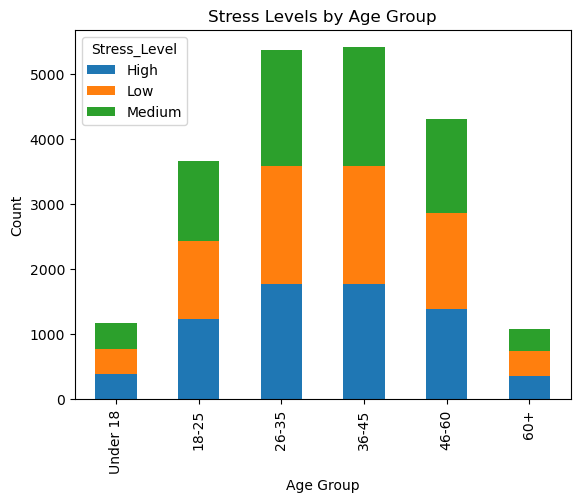

In [34]:
#Stacked view of stress by age bands
combined.groupby(["Age_Band", "Stress_Level"]).size().unstack().plot(
    kind="bar",
    stacked=True
)

import matplotlib.pyplot as plt

plt.title("Stress Levels by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

<Axes: xlabel='Age_Band', ylabel='Social_Media_Usage_Hours'>

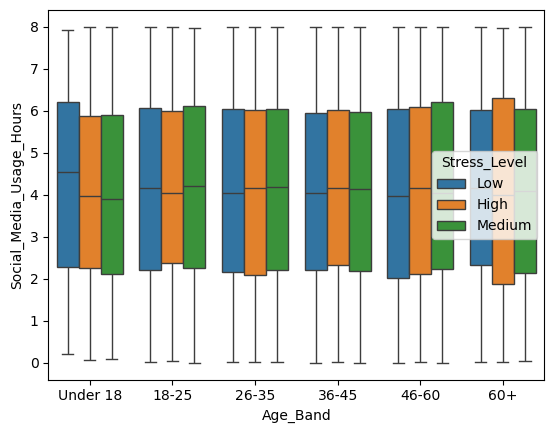

In [41]:
#Social Media varies across age groups, with some age categories reporting fewer activity hours than others
sns.boxplot(
    data=combined,
    x="Age_Band",
    y="Social_Media_Usage_Hours",
    hue="Stress_Level"
)

<Axes: xlabel='Age_Band', ylabel='Screen_Time_Hours'>

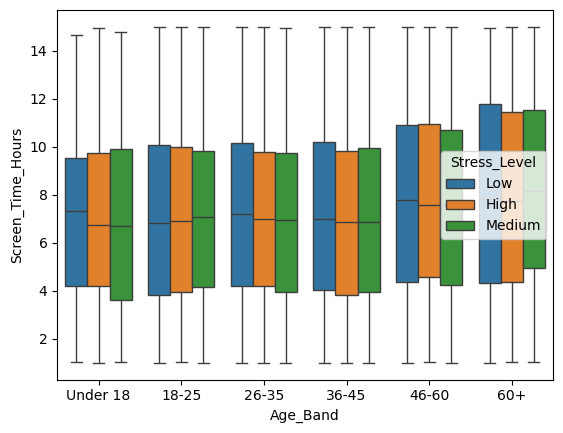

In [42]:
sns.boxplot(
    data=combined,
    x="Age_Band",
    y="Screen_Time_Hours",
    hue="Stress_Level"
)

In [43]:
combined["Stress_Score"] = combined["Stress_Level"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

In [44]:
corr = combined[[
    "Age",
    "Social_Media_Usage_Hours",
    "Screen_Time_Hours",
    "Sleep_Hours",
    "Physical_Activity_Hours",
    "Stress_Score"
]].corr()

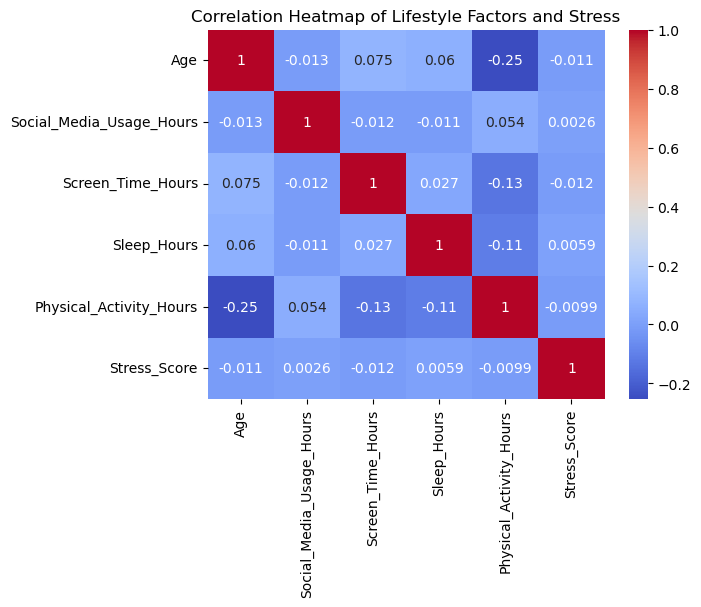

In [47]:
#how does each variable correlate with stress
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Lifestyle Factors and Stress")

plt.show()